# Simple Unit Commitment MILP in Pyomo using GLPK

This notebook formulates and solves a small **Unit Commitment** problem with:

- three thermal generators;
- a 15-hour scheduling horizon;
- binary on/off commitment decisions;
- startup and shutdown decisions;
- continuous generation variables;
- hourly demand balance;
- minimum and maximum generation limits;
- ramp-up and ramp-down constraints;
- variable, no-load, and startup costs.

The load forecast is supplied as a sequence of fixed hourly values. Therefore, it enters the optimization model as parameter data.

In [1]:
import pyomo.environ as pyo
from pyomo.opt import SolverStatus, TerminationCondition

## 2. Define the model and input data

The binary variable $u_{g,t} \in \{0, 1\}$ indicates whether generator $g$ is online during hour $t$.

The binary variable $y_{g,t} \in \{0, 1\}$ indicates whether generator $g$ undergoes startup at time $t$.

The binary variable $z_{g,t} \in \{0, 1\}$ indicates whether generator $g$ undergoes shutdown at time $t$.

The continuous variable $P_{g,t}$ is the electrical output of generator $g$ during hour $t$.

In [2]:
model = pyo.ConcreteModel(name="Simple Unit Commitment")

# Sets
generators = ["Coal", "Gas", "Diesel"]
hours = list(range(1, 16))

model.G = pyo.Set(initialize=generators, ordered=True)
model.T = pyo.Set(initialize=hours, ordered=True)

# Forecast demand in MW
demand = {
    1: 180,
    2: 260,
    3: 420,
    4: 500,
    5: 350,
    6: 220,
    7: 100,
    8: 100,
    9: 250,
    10: 320,
    11: 400,
    12: 350,
    13: 300,
    14: 200,
    15: 100
}

# Generator operating data
p_min = {
    "Coal": 100,
    "Gas": 40,
    "Diesel": 0,
}

p_max = {
    "Coal": 350,
    "Gas": 200,
    "Diesel": 100,
}

variable_cost = {
    "Coal": 20,
    "Gas": 45,
    "Diesel": 80,
}

no_load_cost = {
    "Coal": 500,
    "Gas": 200,
    "Diesel": 50,
}

startup_cost = {
    "Coal": 3000,
    "Gas": 800,
    "Diesel": 100,
}

ramp_up = {
    "Coal": 100,
    "Gas": 120,
    "Diesel": 100,
}

ramp_down = {
    "Coal": 100,
    "Gas": 120,
    "Diesel": 100,
}

# Operating condition immediately before hour 1
initial_on = {
    "Coal": 1,
    "Gas": 0,
    "Diesel": 0,
}

initial_power = {
    "Coal": 180,
    "Gas": 0,
    "Diesel": 0,
}

# Pyomo parameters
model.demand = pyo.Param(model.T, initialize=demand)
model.p_min = pyo.Param(model.G, initialize=p_min)
model.p_max = pyo.Param(model.G, initialize=p_max)
model.variable_cost = pyo.Param(model.G, initialize=variable_cost)
model.no_load_cost = pyo.Param(model.G, initialize=no_load_cost)
model.startup_cost = pyo.Param(model.G, initialize=startup_cost)
model.ramp_up = pyo.Param(model.G, initialize=ramp_up)
model.ramp_down = pyo.Param(model.G, initialize=ramp_down)
model.initial_on = pyo.Param(model.G, initialize=initial_on)
model.initial_power = pyo.Param(model.G, initialize=initial_power)

print("Model data created.")

Model data created.


## 3. Define the decision variables

In [3]:
# Power output in MW
model.power = pyo.Var(
    model.G,
    model.T,
    domain=pyo.NonNegativeReals,
)

# Unit commitment status: 1 if online, 0 if offline
model.on = pyo.Var(
    model.G,
    model.T,
    domain=pyo.Binary,
)

# Startup and shutdown indicators
model.startup = pyo.Var(
    model.G,
    model.T,
    domain=pyo.Binary,
)

model.shutdown = pyo.Var(
    model.G,
    model.T,
    domain=pyo.Binary,
)

print("Decision variables created.")

Decision variables created.


## 4. Objective function

The total cost is

$$
\sum_{g,t}
\left(
c_g^{\mathrm{var}}P_{g,t}
+
c_g^{\mathrm{NL}}u_{g,t}
+
c_g^{\mathrm{SU}}y_{g,t}
\right),
$$

where:

- $c_g^{\mathrm{var}}$ is the variable generation cost;
- $c_g^{\mathrm{NL}}$ is the no-load cost;
- $c_g^{\mathrm{SU}}$ is the startup cost.

In [4]:
def total_cost_rule(m):
    return sum(
        m.variable_cost[g] * m.power[g, t]
        + m.no_load_cost[g] * m.on[g, t]
        + m.startup_cost[g] * m.startup[g, t]
        for g in m.G
        for t in m.T
    )

model.total_cost = pyo.Objective(
    rule=total_cost_rule,
    sense=pyo.minimize,
)

print("Objective function created.")

Objective function created.


## 5. Constraints

### Demand Balance
Sum of all generated power must be enough to match demand at time $t$.
$$ \sum_g P_{g,t} = D_t $$

### Generation Limits
If generator $g$ is ON at time $t$ ($u_{g,t} = 1$), the power produced $P_{g,t}$ must be within the limits. Otherwise, it produces zero power.
$$ P_g^{min}u_{g,t} \leq P_{g,t} \leq P_g^{max}u_{g,t} $$

### Startup and shutdown logic (Commitment transition)
The status change from $u_{g,t-1}$ to $u_{g,t}$ should match the same status change of $y_{g,t}$ and $z_{g,t}$ within the same time $t$.
$$ u_{g,t} - u_{g,t-1} = y_{g,t} - z_{g,t}$$

### No simultaneous startup and shutdown
The $y_{g,t}$ and $z_{g,t}$ can both be zero at time $t$. But if one of them is 1, the other must be 0. They cannot be both 1 at the same time.
$$ y_{g,t} + z_{g,t} \leq 1 $$

### Ramp-up and Ramp-down Constraints
While generators are running, their power output is not allowed to jump more than $R_g^{up}$ nor drop more than $R_g^{down}$ from $t-1$ to $t$. But during startup and shutdown, these constraints are relaxed.  

$$ P_{g,t} - P_{g,t-1} \leq R_g^{up} + P_g^{max}y_{g,t} $$
$$ P_{g,t-1} - P_{g,t} \leq R_g^{down} + P_g^{max}z_{g,t} $$

In [5]:
# Demand balance
def demand_balance_rule(m, t):
    return sum(m.power[g, t] for g in m.G) == m.demand[t]

model.demand_balance = pyo.Constraint(
    model.T,
    rule=demand_balance_rule,
)


# Minimum generation
def minimum_generation_rule(m, g, t):
    return m.power[g, t] >= m.p_min[g] * m.on[g, t]

model.minimum_generation = pyo.Constraint(
    model.G,
    model.T,
    rule=minimum_generation_rule,
)


# Maximum generation
def maximum_generation_rule(m, g, t):
    return m.power[g, t] <= m.p_max[g] * m.on[g, t]

model.maximum_generation = pyo.Constraint(
    model.G,
    model.T,
    rule=maximum_generation_rule,
)


# Commitment transition:
# on_t - on_(t-1) = startup_t - shutdown_t
def commitment_transition_rule(m, g, t):
    if t == m.T.first():
        return (
            m.on[g, t] - m.initial_on[g]
            == m.startup[g, t] - m.shutdown[g, t]
        )

    previous_t = m.T.prev(t)
    return (
        m.on[g, t] - m.on[g, previous_t]
        == m.startup[g, t] - m.shutdown[g, t]
    )

model.commitment_transition = pyo.Constraint(
    model.G,
    model.T,
    rule=commitment_transition_rule,
)


# A unit cannot start and shut down simultaneously
def mutually_exclusive_transition_rule(m, g, t):
    return m.startup[g, t] + m.shutdown[g, t] <= 1

model.mutually_exclusive_transition = pyo.Constraint(
    model.G,
    model.T,
    rule=mutually_exclusive_transition_rule,
)


# Ramp-up constraint
def ramp_up_rule(m, g, t):
    if t == m.T.first():
        previous_power = m.initial_power[g]
    else:
        previous_power = m.power[g, m.T.prev(t)]

    return (
        m.power[g, t] - previous_power
        <= m.ramp_up[g] + m.p_max[g] * m.startup[g, t]
    )

model.ramp_up_constraint = pyo.Constraint(
    model.G,
    model.T,
    rule=ramp_up_rule,
)


# Ramp-down constraint
def ramp_down_rule(m, g, t):
    if t == m.T.first():
        previous_power = m.initial_power[g]
    else:
        previous_power = m.power[g, m.T.prev(t)]

    return (
        previous_power - m.power[g, t]
        <= m.ramp_down[g] + m.p_max[g] * m.shutdown[g, t]
    )

model.ramp_down_constraint = pyo.Constraint(
    model.G,
    model.T,
    rule=ramp_down_rule,
)

print("Constraints created.")

Constraints created.


## 6. Solve with GLPK

The model is an MILP because all constraints and costs are linear, while the commitment, startup, and shutdown variables are binary.

In [6]:
solver = pyo.SolverFactory("glpk")

if not solver.available(exception_flag=False):
    raise RuntimeError(
        "GLPK is not available. Install GLPK and make sure that "
        "'glpsol' is available on your system PATH."
    )

results = solver.solve(model, tee=True)

print("\nSolver status:", results.solver.status)
print("Termination condition:", results.solver.termination_condition)

acceptable = (
    results.solver.status == SolverStatus.ok
    and results.solver.termination_condition
    in {
        TerminationCondition.optimal,
        TerminationCondition.feasible,
    }
)

if not acceptable:
    raise RuntimeError("GLPK did not return an acceptable solution.")

GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write C:\Users\Karl\AppData\Local\Temp\tmplur78om3.glpk.raw --wglp C:\Users\Karl\AppData\Local\Temp\tmpbom2iu3i.glpk.glp
 --cpxlp C:\Users\Karl\AppData\Local\Temp\tmp4j2k0047.pyomo.lp
Reading problem data from 'C:\Users\Karl\AppData\Local\Temp\tmp4j2k0047.pyomo.lp'...
C:\Users\Karl\AppData\Local\Temp\tmp4j2k0047.pyomo.lp:1921: warning: lower bound of variable 'x47' redefined
C:\Users\Karl\AppData\Local\Temp\tmp4j2k0047.pyomo.lp:1921: warning: upper bound of variable 'x47' redefined
285 rows, 180 columns, 741 non-zeros
135 integer variables, all of which are binary
2056 lines were read
Writing problem data to 'C:\Users\Karl\AppData\Local\Temp\tmpbom2iu3i.glpk.glp'...
1630 lines were written
GLPK Integer Optimizer 5.0
285 rows, 180 columns, 741 non-zeros
135 integer variables, all of which are binary
Preprocessing...
61 constraint coefficient(s) were reduced
219 rows, 174 columns, 571 non-zeros
129 integer vari

## 7. Display the optimal schedule

In [7]:
print(f"Total operating cost = ${pyo.value(model.total_cost):,.2f}\n")

header = (
    f"{'Hour':>4} {'Demand':>8} "
    + " ".join(
        f"{g + ' ON':>10} {g + ' MW':>10}"
        for g in model.G
    )
)

print(header)
print("-" * len(header))

for t in model.T:
    row = f"{t:>4} {pyo.value(model.demand[t]):>8.1f}"

    for g in model.G:
        row += (
            f" {int(round(pyo.value(model.on[g, t]))):>10}"
            f" {pyo.value(model.power[g, t]):>10.1f}"
        )

    print(row)

Total operating cost = $102,900.00

Hour   Demand    Coal ON    Coal MW     Gas ON     Gas MW  Diesel ON  Diesel MW
-------------------------------------------------------------------------------
   1    180.0          1      180.0          0        0.0          0        0.0
   2    260.0          1      260.0          0        0.0          0        0.0
   3    420.0          1      350.0          1       70.0          0        0.0
   4    500.0          1      350.0          1      150.0          0        0.0
   5    350.0          1      300.0          1       50.0          0        0.0
   6    220.0          1      200.0          0        0.0          1       20.0
   7    100.0          1      100.0          0        0.0          0        0.0
   8    100.0          1      100.0          0        0.0          0        0.0
   9    250.0          1      200.0          1       50.0          0        0.0
  10    320.0          1      280.0          1       40.0          0        0.0
  11

In [8]:
print("Startup schedule")
print("----------------")

for t in model.T:
    started_units = [
        g
        for g in model.G
        if pyo.value(model.startup[g, t]) > 0.5
    ]

    text = ", ".join(started_units) if started_units else "None"
    print(f"Hour {t}: {text}")

Startup schedule
----------------
Hour 1: None
Hour 2: None
Hour 3: Gas
Hour 4: None
Hour 5: None
Hour 6: Diesel
Hour 7: None
Hour 8: None
Hour 9: Gas
Hour 10: None
Hour 11: None
Hour 12: None
Hour 13: None
Hour 14: None
Hour 15: None


## 8. Optional: Convert the schedule to a pandas table

In [9]:
import pandas as pd

rows = []

for t in model.T:
    row = {
        "Hour": t,
        "Demand_MW": pyo.value(model.demand[t]),
    }

    for g in model.G:
        row[f"{g}_On"] = int(round(pyo.value(model.on[g, t])))
        row[f"{g}_Power_MW"] = pyo.value(model.power[g, t])
        row[f"{g}_Startup"] = int(
            round(pyo.value(model.startup[g, t]))
        )

    rows.append(row)

schedule = pd.DataFrame(rows)
schedule

,Hour,Demand_MW,Coal_On,Coal_Power_MW,Coal_Startup,Gas_On,Gas_Power_MW,Gas_Startup,Diesel_On,Diesel_Power_MW,Diesel_Startup
0,1,180,1,180.0,0,0,0.0,0,0,0.0,0
1,2,260,1,260.0,0,0,0.0,0,0,0.0,0
2,3,420,1,350.0,0,1,70.0,1,0,0.0,0
3,4,500,1,350.0,0,1,150.0,0,0,0.0,0
4,5,350,1,300.0,0,1,50.0,0,0,0.0,0
5,6,220,1,200.0,0,0,0.0,0,1,20.0,1
6,7,100,1,100.0,0,0,0.0,0,0,0.0,0
7,8,100,1,100.0,0,0,0.0,0,0,0.0,0
8,9,250,1,200.0,0,1,50.0,1,0,0.0,0
9,10,320,1,280.0,0,1,40.0,0,0,0.0,0


## Plotting Results

This example omits several constraints commonly used in realistic Unit Commitment models:

- minimum up time;
- minimum down time;
- spinning and non-spinning reserves;
- transmission-network constraints;
- piecewise-linear heat-rate curves;
- startup trajectories;
- renewable curtailment;
- storage;
- contingency constraints.

These can be added while preserving an MILP formulation, provided they are expressed through linear constraints and binary or continuous decision variables.

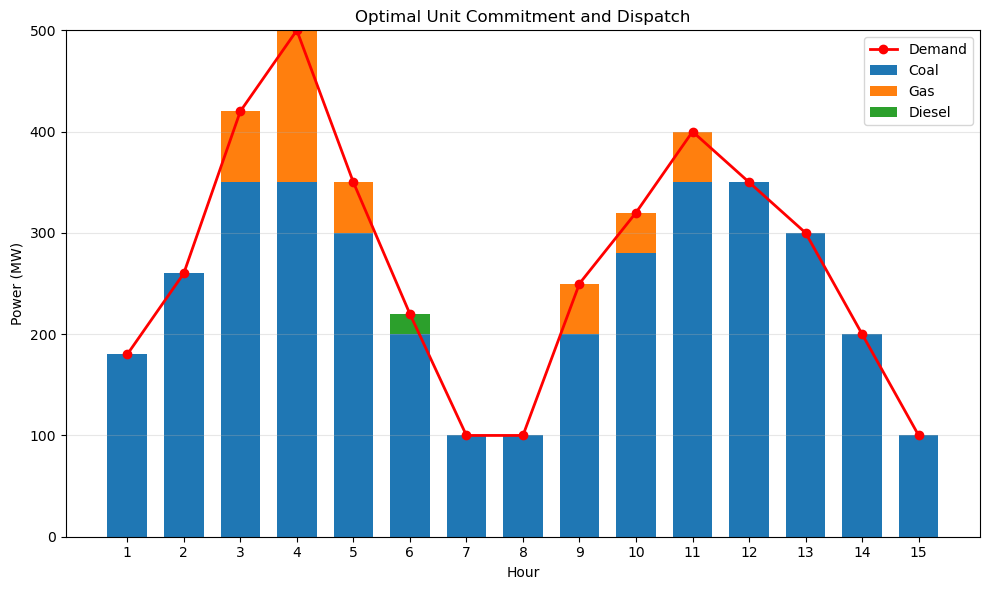

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Extract the optimized schedule from the Pyomo model
hours = list(model.T)
generators = list(model.G)

generation = {
    g: np.array(
        [pyo.value(model.power[g, t]) for t in hours],
        dtype=float,
    )
    for g in generators
}

demand_values = np.array(
    [pyo.value(model.demand[t]) for t in hours],
    dtype=float,
)

# Use numeric positions so the line passes through the centers of the bars
x = np.arange(len(hours))
bottom = np.zeros(len(hours))

fig, ax = plt.subplots(figsize=(10, 6))

# Stacked generator outputs
for g in generators:
    ax.bar(
        x,
        generation[g],
        bottom=bottom,
        label=g,
        width=0.7,
    )
    bottom += generation[g]

# Forecast demand
ax.plot(x, demand_values, "ro-",
    linewidth=2, label="Demand"
)

ax.set_title("Optimal Unit Commitment and Dispatch")
ax.set_xlabel("Hour")
ax.set_ylabel("Power (MW)")
ax.set_xticks(x)
ax.set_xticklabels(hours)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()